Exploration Data Analysis (EDA)
-

**Explicació de la tarifa segons Aigües de Barcelona:** https://www.aiguesdebarcelona.cat/ca/el-teu-servei-daigua/la-teva-factura-i-tarifes/tarifes-de-subministrament

1. Quota de servei (part fixa): AB aplica una quota fixa que paga l’abonat per tenir el servei disponible (comptador, xarxa, potabilització).

2. Consum d’aigua (part variable): El consum es factura en blocs creixents: a més volum consumit, més euro/m³.

3. Altres conceptes impositius: A la factura s’afegeixen: el cànon de l’aigua, la taxa de clavegueram, l’IVA i altres.

4. Estructura general: L’import total = Quota fixa + (Consum × preu segons tram) + Tributs + Impostos.

5. Butlleta de tarifes: Per exemple, AB publica que per subministraments domèstics la tarifa vigent té 5 trams i que el límit dels primers tràms pot canviar segons nombre de persones de l’habitatge.

# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
from google.colab import drive

# Data Preu Aigua per Municipi

## Load Data

In [2]:
drive.mount('/content/drive')
csv_path = "/content/drive/Shared drives/Gestió de Projectes/Projecte/data/Preus_per_municipi/Preus_municipi_ca.csv"

df_preu = pd.read_csv(csv_path, sep=';', encoding='utf-8')
print("Loaded rows:", len(df_preu))
print("CSV loaded correctly")


Mounted at /content/drive
Loaded rows: 947
CSV loaded correctly


## General Info

In [3]:
print("First five rows:\n")
df_preu.head()

First five rows:



,Idescat,Municipi,Comarca,Subministrament\n€/m³,Cànon de l'aigua\n€/m³,Clavegueram\n€/m³,TOTAL\n€/m³,Entitat gestora principal\nSubministrament,Gestió Subministrament,Gestió Clavegueram,(*),Tarifes socials,Data revisió
0,250019,Abella de la Conca,Pallars Jussà,"0,15","0,433",0,"0,583",Ajuntament D'Abella De La Conca,Directa,Directa,NaN,NaN,15/3/2022
1,80018,Abrera,Baix Llobregat,"0,742","0,654",0,"1,396",Ajuntament D'Abrera,Directa,Directa,NaN,NaN,15/3/2022
2,250024,Àger,Noguera,"1,36","0,654",0,"2,014","Cia. General Aigües De Catalunya, Sa",Indirecta,Directa,*,NaN,20/6/2022
3,250030,Agramunt,Urgell,"0,843","0,654","0,072","1,569","Cassa Aigües I Depuració, Sl",Indirecta,Directa,*,Si,5/6/2024
4,80023,Aguilar de Segarra,Bages,"1,973","0,433","0,348","2,754",Ajuntament D'Aguilar De Segarra,Directa,Directa,*,NaN,15/4/2024


In [4]:
print("\nData types:\n", df_preu.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 13 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Idescat                                    947 non-null    int64 
 1   Municipi                                   947 non-null    object
 2   Comarca                                    947 non-null    object
 3   Subministrament
€/m³                       947 non-null    object
 4   Cànon de l'aigua
€/m³                      947 non-null    object
 5   Clavegueram
€/m³                           947 non-null    object
 6   TOTAL
€/m³                                 947 non-null    object
 7   Entitat gestora principal
Subministrament  947 non-null    object
 8   Gestió Subministrament                     947 non-null    object
 9   Gestió Clavegueram                         947 non-null    object
 10  (*)                                   

Podem veure que el DataType no coincideix, per tant, cal netejar i convertir aqueste columnes. Farem:


1.   Netega el noms de les columnes (treure salts de línea i corregir unitats.)
2.   Subtituir comes decimals per punts i elimna caràcters que puguin impedir la conversió.
1.   Convertir les columnes "Subministrament (€/m³)", "Cànon de l'aigua (€/m³)", "Clavegueram (€/m³)"i "TOTAL (€/m³)" de presus a float.
2.   Convertir Data revisió a datetime64[ns] (amb dayfirst=True).
1.   Mostrar un resum valors.
2.   Guardar el DataFrame net com a CSV.







In [5]:
#Ruta on guardarem el nou datset net

output_path = "/content/drive/Shared drives/Gestió de Projectes/Projecte/data/Preus_per_municipi/Preus_municipi_ca_clean.csv"

In [6]:
df_preu.columns = (
    df_preu.columns
    .str.replace('\n', ' ', regex=True)           # treu salts de línia
    .str.replace('€/m³', '(€/m³)', regex=False)   # posa unitat entre parèntesis
    .str.replace(r'\s{2,}', ' ', regex=True)      # elimina espais dobles
    .str.strip()                                  # elimina espais al principi i final
)

print("\nColumns after rename:\n", df_preu.columns.tolist())


Columns after rename:
 ['Idescat', 'Municipi', 'Comarca', 'Subministrament (€/m³)', "Cànon de l'aigua (€/m³)", 'Clavegueram (€/m³)', 'TOTAL (€/m³)', 'Entitat gestora principal Subministrament', 'Gestió Subministrament', 'Gestió Clavegueram', '(*)', 'Tarifes socials', 'Data revisió']


In [7]:
# Defineix les columnes numèriques i la de data
num_cols_raw = [
    "Subministrament (€/m³)",
    "Cànon de l'aigua (€/m³)",
    "Clavegueram (€/m³)",
    "TOTAL (€/m³)"
]
date_col = "Data revisió"

# En cas que algun nom exact difereixi, revisa i mapa:
for c in num_cols_raw:
    if c not in df_preu.columns:
        print(f"WARNING: column '{c}' not found in dataframe. Available columns:\n{df_preu.columns.tolist()}")
        # atura o ajusta el nom manualment si cal
        # raise KeyError(c)

In [8]:
# Normalitza strings i converteix a float
def to_float_series(s):
    # treu espais, substitueix coma decimal per punt i elimina altres caràcters problemàtics
    s_clean = s.astype(str).str.strip().str.replace(r'\s+', '', regex=True)
    s_clean = s_clean.str.replace(',', '.', regex=False) # coma decimal -> punt
    s_clean = s_clean.str.replace(r'[^\d\.\-]', '', regex=True) # elimina tot el que no sigui nombre, punt o signe menys
    # converteix a float, deixant NaN on no es pugui
    return pd.to_numeric(s_clean, errors='coerce')

for col in num_cols_raw:
    df_preu[col] = to_float_series(df_preu[col])

df_preu[date_col] = pd.to_datetime(df_preu[date_col], dayfirst=True, errors='coerce')

print("\nData types after conversion:\n")
print(df_preu.dtypes)


Data types after conversion:

Idescat                                               int64
Municipi                                             object
Comarca                                              object
Subministrament (€/m³)                              float64
Cànon de l'aigua (€/m³)                             float64
Clavegueram (€/m³)                                  float64
TOTAL (€/m³)                                        float64
Entitat gestora principal Subministrament            object
Gestió Subministrament                               object
Gestió Clavegueram                                   object
(*)                                                  object
Tarifes socials                                      object
Data revisió                                 datetime64[ns]
dtype: object


In [9]:
print("Null value counts:\n", df_preu.isnull().sum())

Null value counts:
 Idescat                                        0
Municipi                                       0
Comarca                                        0
Subministrament (€/m³)                         2
Cànon de l'aigua (€/m³)                        0
Clavegueram (€/m³)                            18
TOTAL (€/m³)                                   0
Entitat gestora principal Subministrament      0
Gestió Subministrament                         0
Gestió Clavegueram                             0
(*)                                          275
Tarifes socials                              576
Data revisió                                   0
dtype: int64


In [10]:
# Guarda dataset net
df_preu.to_csv(output_path, index=False, encoding='utf-8')
print(f"\n Clean dataset saved successfully to: {output_path}")


 Clean dataset saved successfully to: /content/drive/Shared drives/Gestió de Projectes/Projecte/data/Preus_per_municipi/Preus_municipi_ca_clean.csv


## Visual Exploration

In [11]:
print("\nBasic statistical summary:\n")
display(df_preu[num_cols_raw].describe())

print(f"\n Average total water price: {df_preu['TOTAL (€/m³)'].mean():.3f} €/m³")
print(f"Most expensive municipality: {df_preu.loc[df_preu['TOTAL (€/m³)'].idxmax(), 'Municipi']}")
print(f"Cheapest municipality: {df_preu.loc[df_preu['TOTAL (€/m³)'].idxmin(), 'Municipi']}")



Basic statistical summary:



,Subministrament (€/m³),Cànon de l'aigua (€/m³),Clavegueram (€/m³),TOTAL (€/m³)
count,945.000000,947.000000,929.000000,947.000000
mean,1.001983,0.582347,0.121813,1.699600
std,0.517698,0.102004,0.143823,0.564764
min,0.000000,0.433000,0.000000,0.433000
25%,0.623000,0.433000,0.000000,1.278000
50%,0.957000,0.654000,0.104000,1.688000
75%,1.312000,0.654000,0.178000,2.065000
max,2.784000,0.654000,2.000000,3.662000



 Average total water price: 1.700 €/m³
Most expensive municipality: Canyelles
Cheapest municipality: Arres


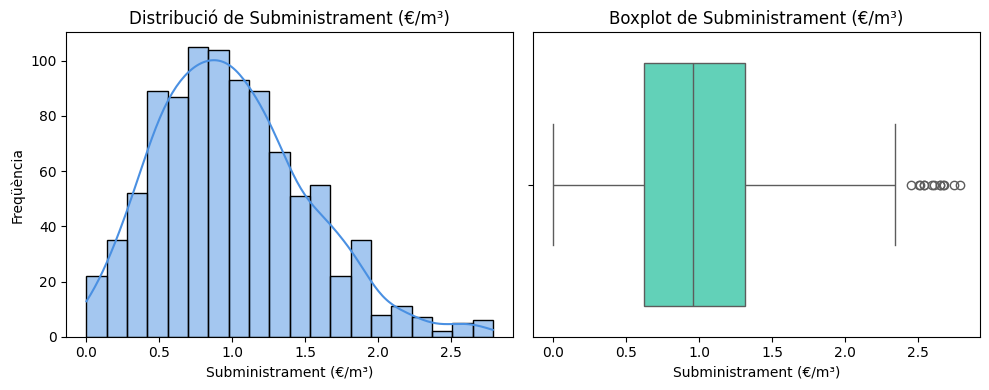

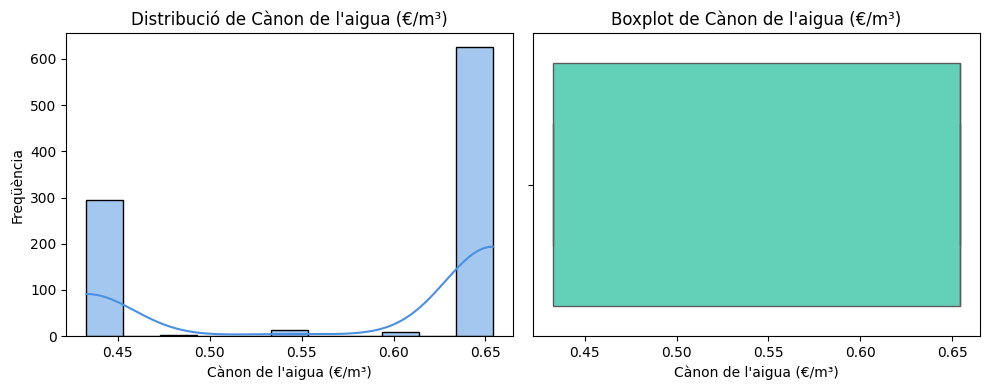

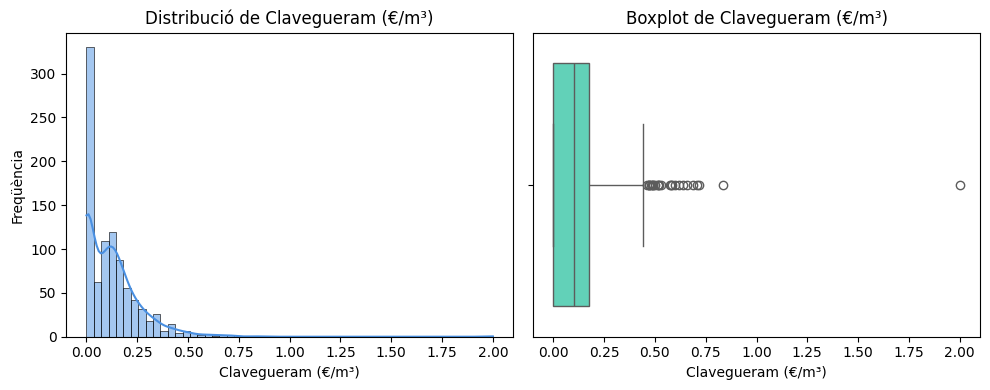

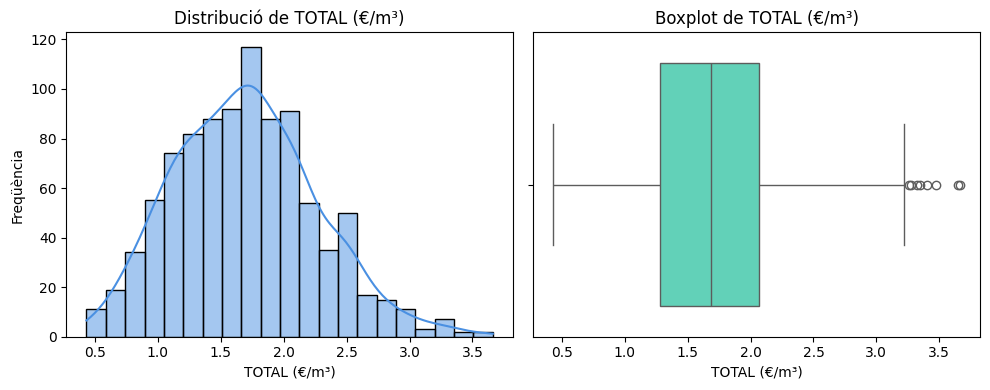

In [12]:
# Distribució dels preus de les columnes numèriques (histogrames i boxplots)
for col in num_cols_raw:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Histograma
    sns.histplot(df_preu[col], kde=True, ax=axes[0], color="#4A90E2")
    axes[0].set_title(f"Distribució de {col}", fontsize=12)
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Freqüència")

    # Boxplot
    sns.boxplot(x=df_preu[col], ax=axes[1], color="#50E3C2")
    axes[1].set_title(f"Boxplot de {col}", fontsize=12)
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

/tmp/ipython-input-2172714652.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_by_comarca.head(15).values, y=avg_by_comarca.head(15).index, palette="crest")


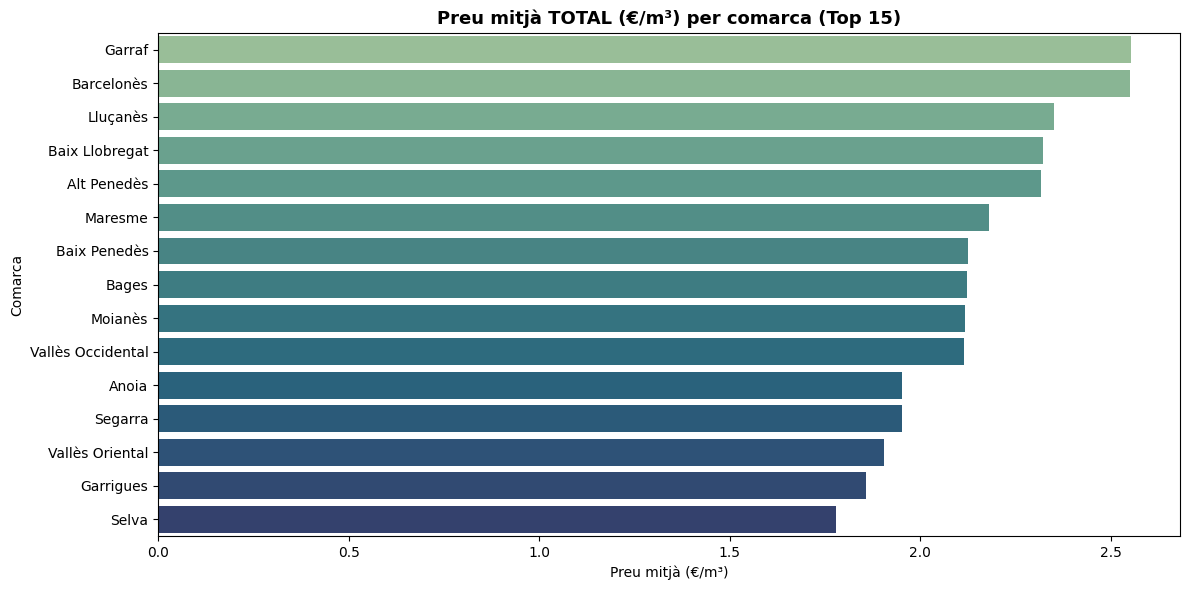

In [13]:
# Distribució del TOTAL per comarca
plt.figure(figsize=(12, 6))
avg_by_comarca = df_preu.groupby("Comarca")["TOTAL (€/m³)"].mean().sort_values(ascending=False)
sns.barplot(x=avg_by_comarca.head(15).values, y=avg_by_comarca.head(15).index, palette="crest")
plt.title("Preu mitjà TOTAL (€/m³) per comarca (Top 15)", fontsize=13, fontweight="bold")
plt.xlabel("Preu mitjà (€/m³)")
plt.ylabel("Comarca")
plt.tight_layout()
plt.show()

/tmp/ipython-input-2668606488.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_preu, x="Gestió Subministrament", y="TOTAL (€/m³)", palette="Set2")


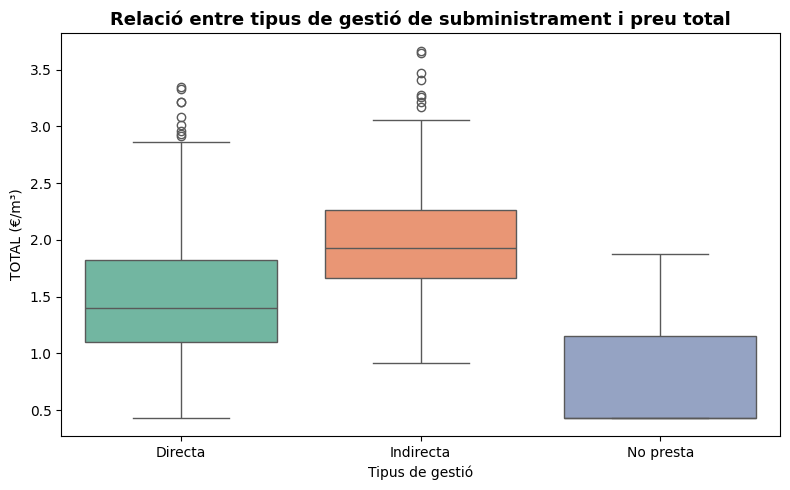

/tmp/ipython-input-2668606488.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_preu, x="Gestió Clavegueram", y="TOTAL (€/m³)", palette="Set3")


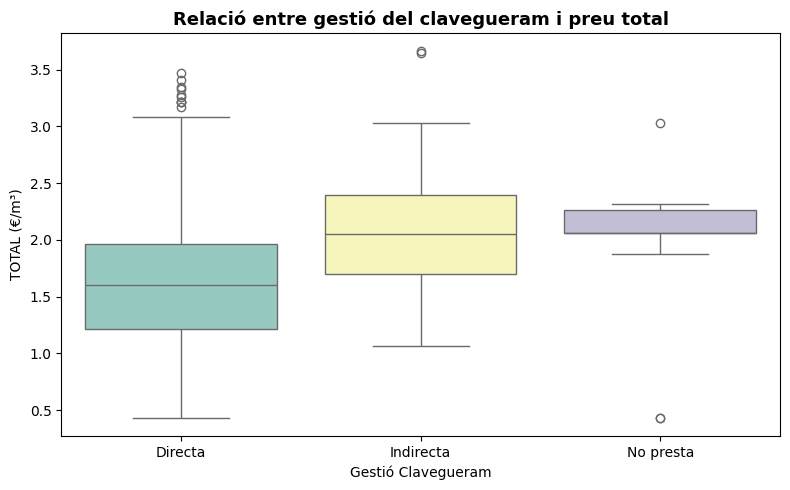

In [14]:
# Relació entre tipus de gestió i preus
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_preu, x="Gestió Subministrament", y="TOTAL (€/m³)", palette="Set2")
plt.title("Relació entre tipus de gestió de subministrament i preu total", fontsize=13, fontweight="bold")
plt.xlabel("Tipus de gestió")
plt.ylabel("TOTAL (€/m³)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_preu, x="Gestió Clavegueram", y="TOTAL (€/m³)", palette="Set3")
plt.title("Relació entre gestió del clavegueram i preu total", fontsize=13, fontweight="bold")
plt.xlabel("Gestió Clavegueram")
plt.ylabel("TOTAL (€/m³)")
plt.tight_layout()
plt.show()


Generating barplots for categorical columns...


/tmp/ipython-input-2622509880.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.values, y=value_counts.index, palette="Blues_d")


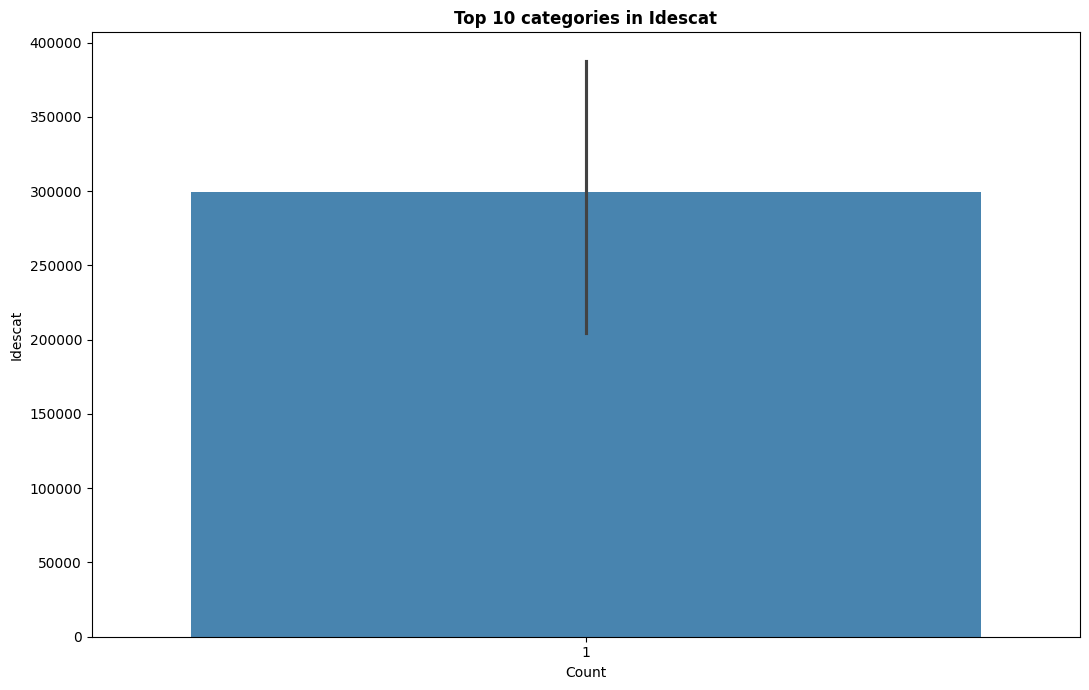

/tmp/ipython-input-2622509880.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.values, y=value_counts.index, palette="Blues_d")


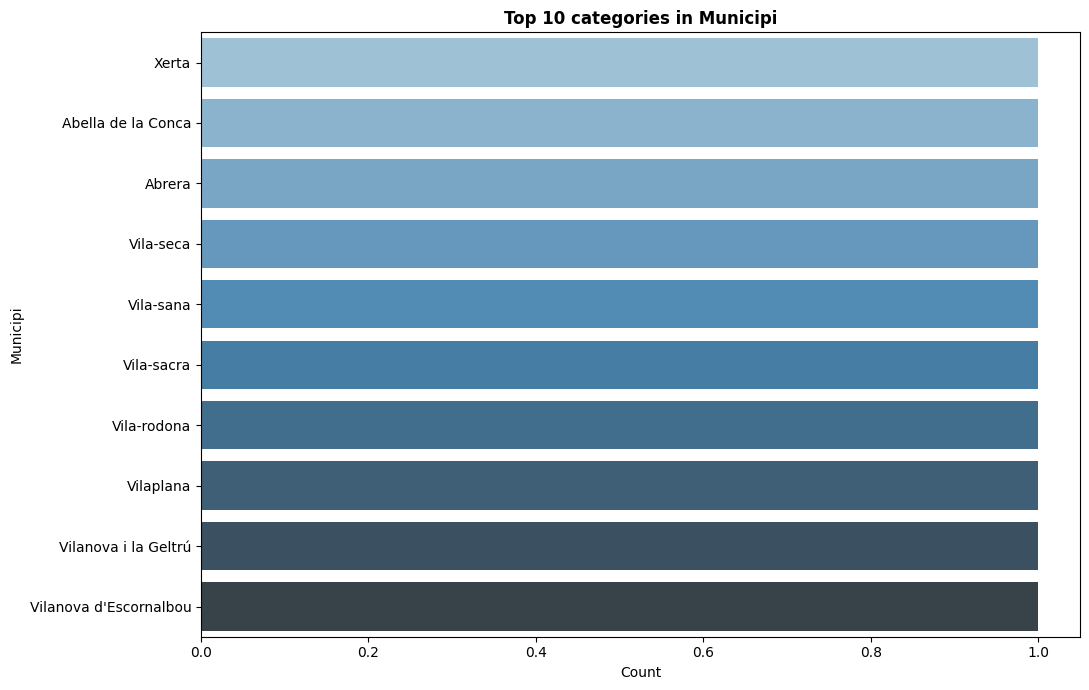

/tmp/ipython-input-2622509880.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.values, y=value_counts.index, palette="Blues_d")


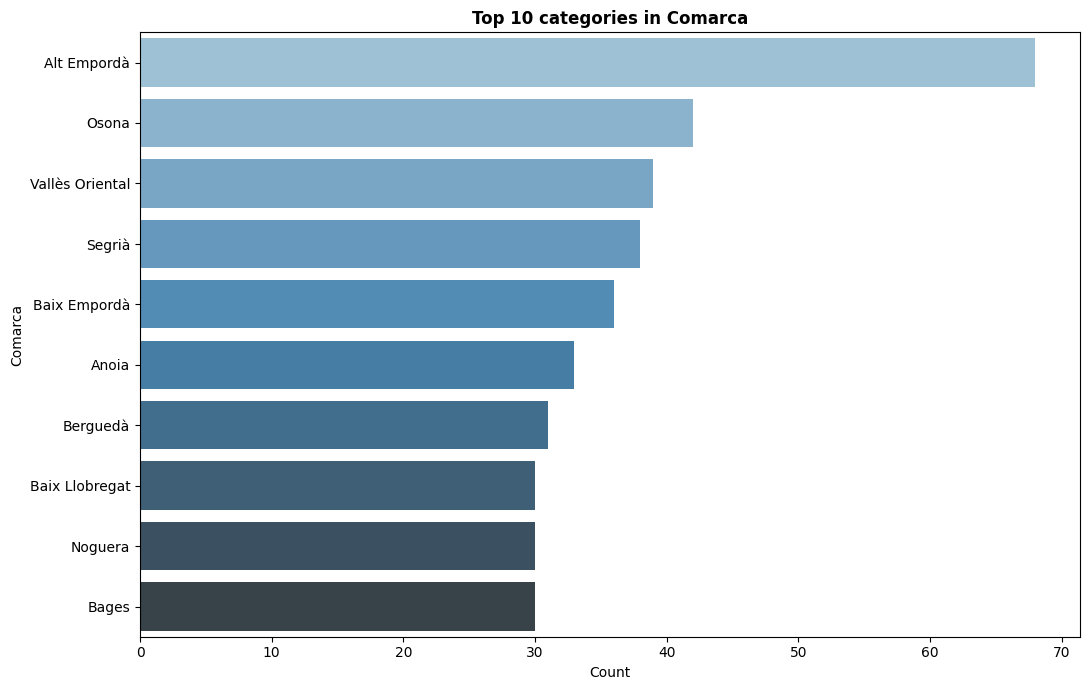

/tmp/ipython-input-2622509880.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.values, y=value_counts.index, palette="Blues_d")


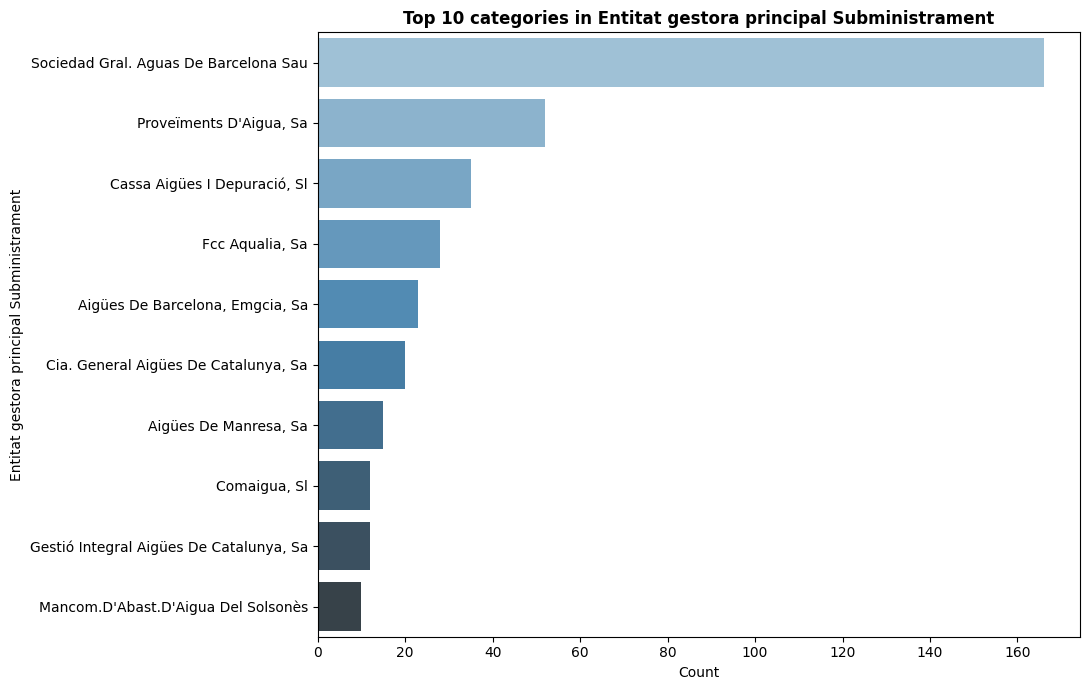

/tmp/ipython-input-2622509880.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.values, y=value_counts.index, palette="Blues_d")


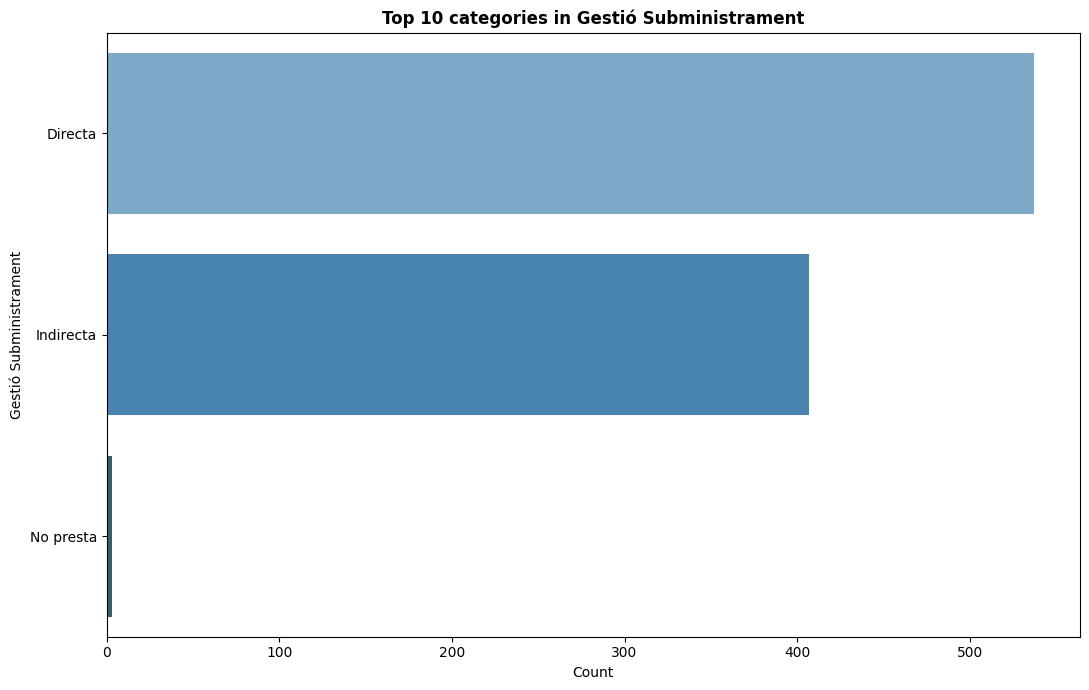

/tmp/ipython-input-2622509880.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.values, y=value_counts.index, palette="Blues_d")


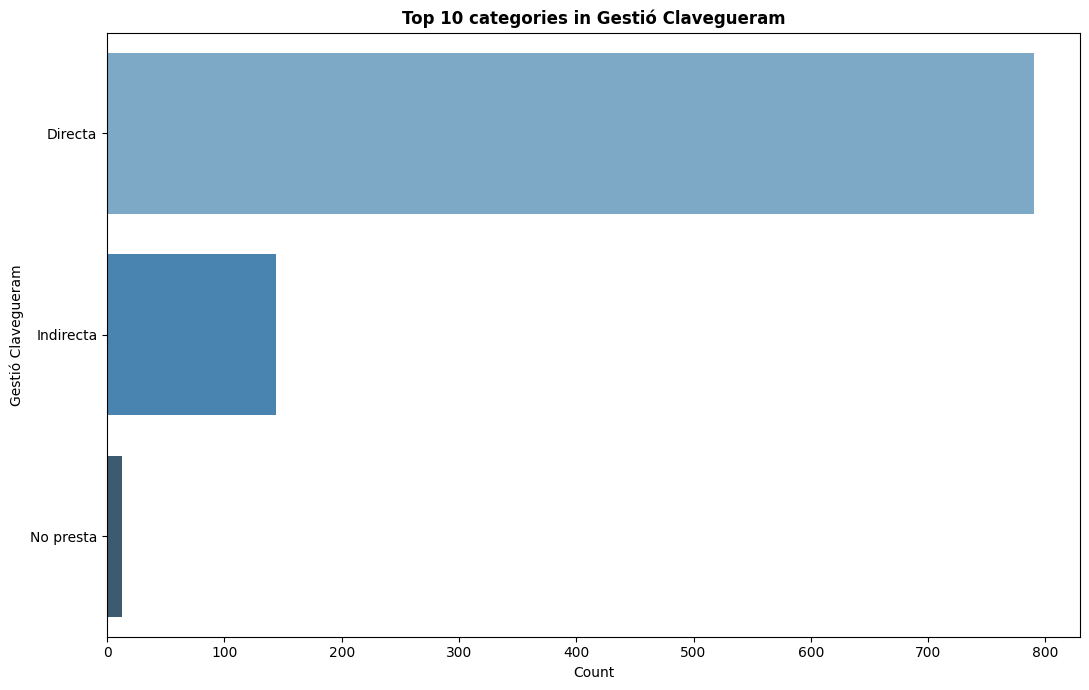

/tmp/ipython-input-2622509880.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.values, y=value_counts.index, palette="Blues_d")


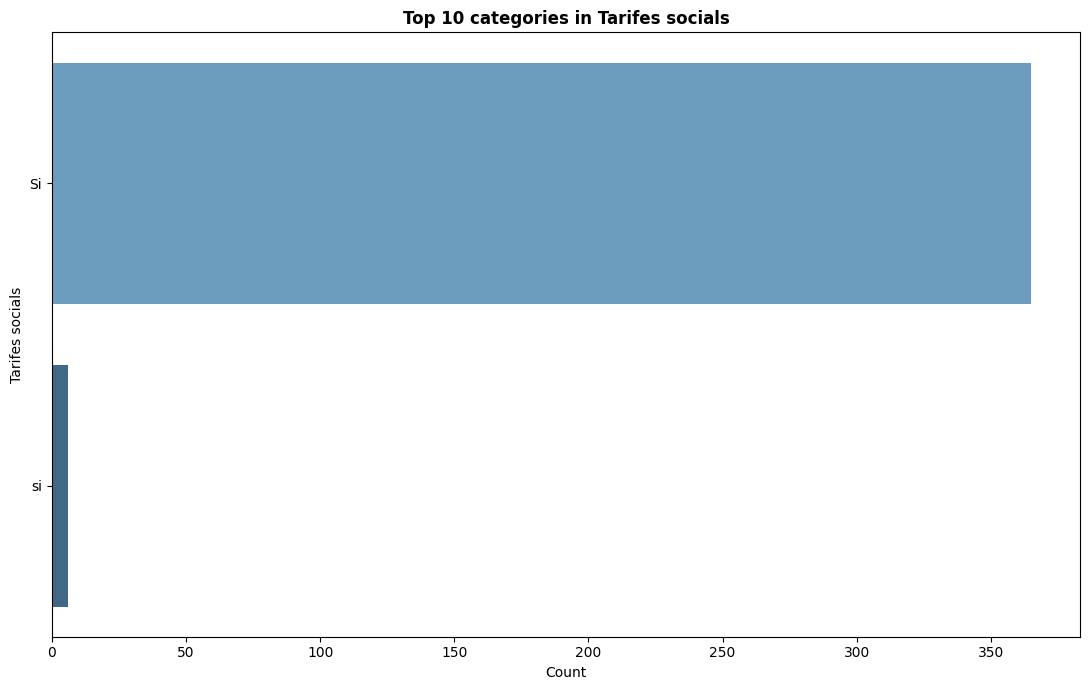

In [15]:
print("\nGenerating barplots for categorical columns...")
cat_cols = ["Idescat", "Municipi", "Comarca", "Entitat gestora principal Subministrament", "Gestió Subministrament", "Gestió Clavegueram", "Tarifes socials"]

for col in cat_cols:
    value_counts = df_preu[col].value_counts().head(10)
    plt.figure(figsize=(11, 7))
    sns.barplot(x=value_counts.values, y=value_counts.index, palette="Blues_d")
    plt.title(f"Top 10 categories in {col}", fontsize=12, fontweight="bold")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


Generating time distribution plots for datetime columns...


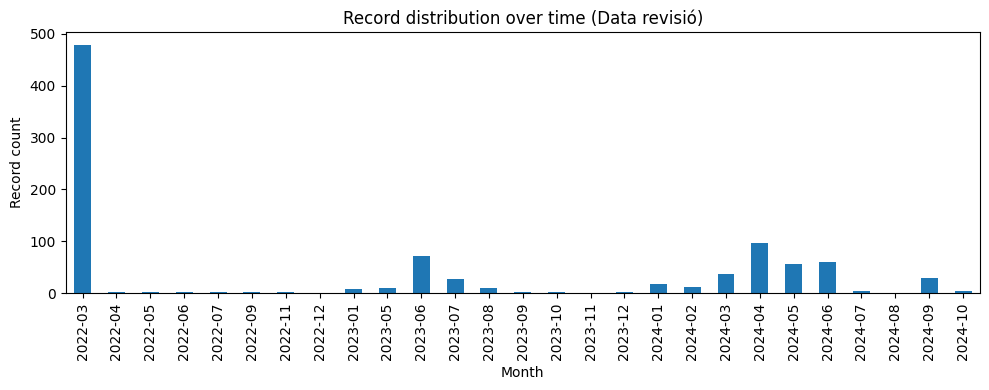

In [16]:
print("\nGenerating time distribution plots for datetime columns...")
date_cols = ["Data revisió"]
for col in date_cols:
    plt.figure(figsize=(10, 4))
    df_preu[col].dt.to_period('M').value_counts().sort_index().plot(kind='bar')
    plt.title(f"Record distribution over time ({col})")
    plt.xlabel("Month")
    plt.ylabel("Record count")
    plt.tight_layout()
    plt.show()

## Correlation


 Matriu de correlació:
                          Subministrament (€/m³)  Cànon de l'aigua (€/m³)  \
Subministrament (€/m³)                    1.000                    0.040   
Cànon de l'aigua (€/m³)                   0.040                    1.000   
Clavegueram (€/m³)                        0.127                    0.069   
TOTAL (€/m³)                              0.954                    0.236   

                         Clavegueram (€/m³)  TOTAL (€/m³)  
Subministrament (€/m³)                0.127         0.954  
Cànon de l'aigua (€/m³)               0.069         0.236  
Clavegueram (€/m³)                    1.000         0.333  
TOTAL (€/m³)                          0.333         1.000  


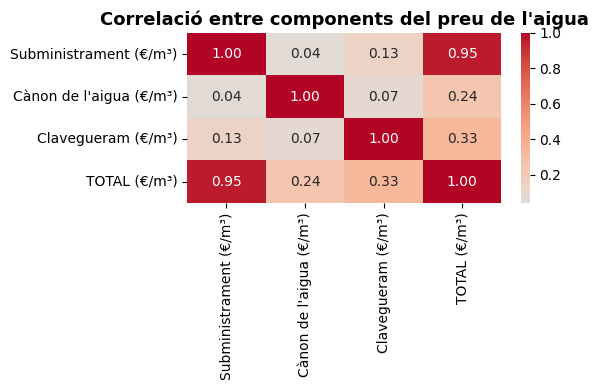

In [17]:
# Correlació entre variables numèriques
corr_matrix = df_preu[num_cols_raw].corr(method='pearson')
print("\n Matriu de correlació:\n", corr_matrix.round(3))

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlació entre components del preu de l'aigua", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

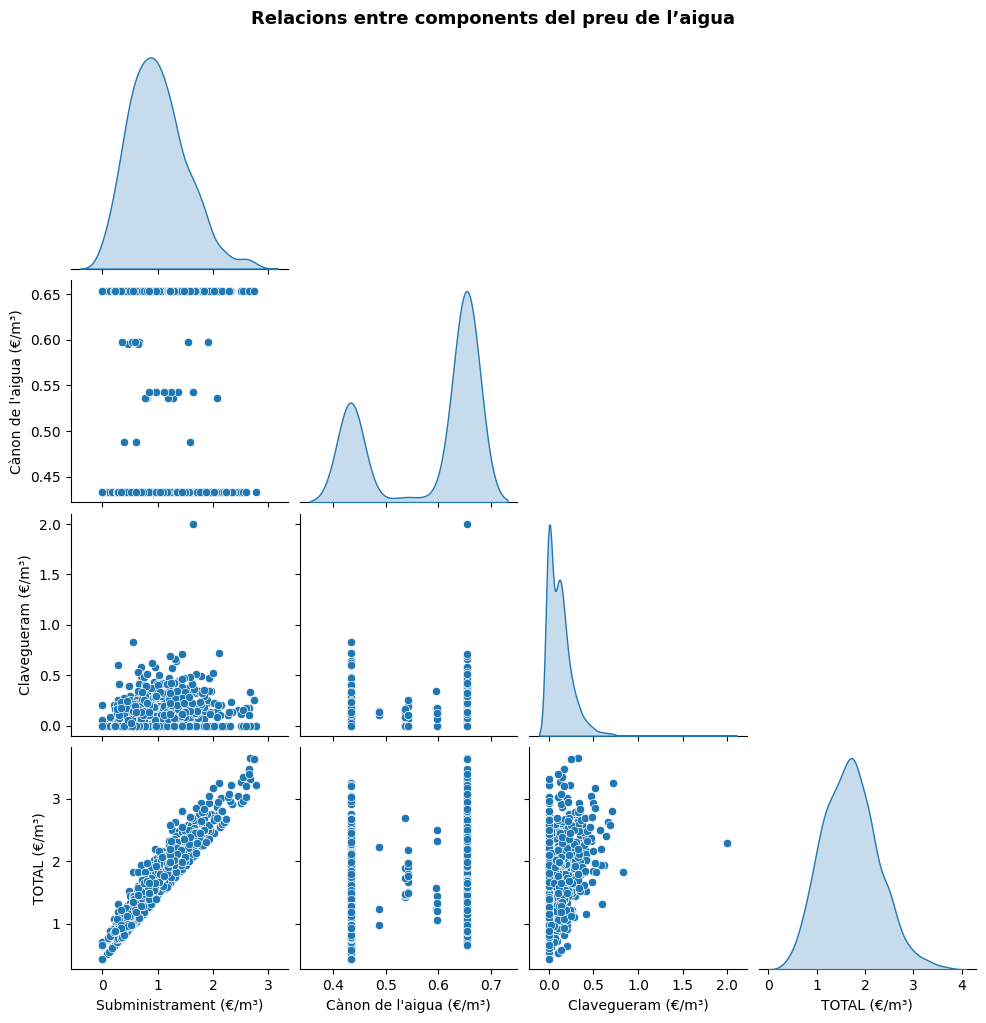

In [18]:
# Scatterplot per veure relacions entre components
sns.pairplot(df_preu[num_cols_raw], diag_kind="kde", corner=True)
plt.suptitle("Relacions entre components del preu de l’aigua", y=1.02, fontsize=13, fontweight="bold")
plt.show()

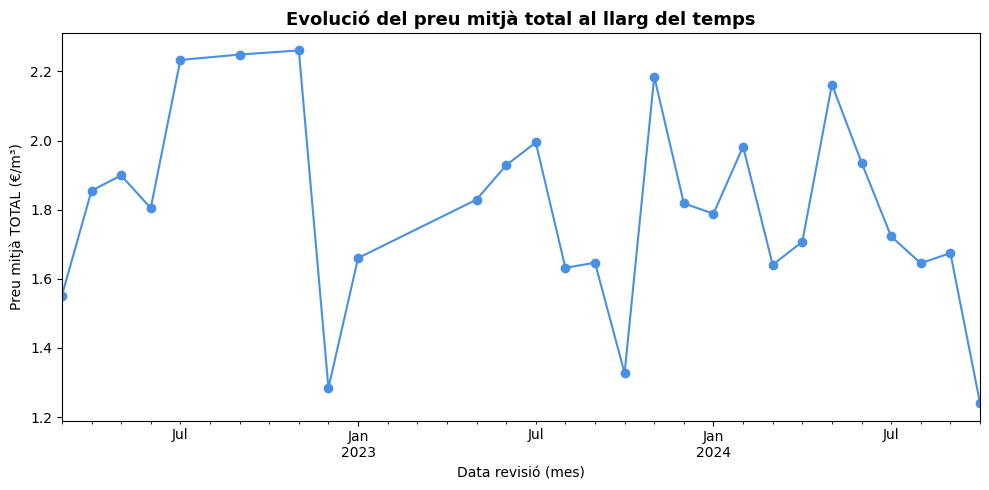

In [19]:
# Anàlisi temporal (si hi ha diverses dates de revisió)
plt.figure(figsize=(10, 5))
df_preu.groupby(df_preu["Data revisió"].dt.to_period("M"))["TOTAL (€/m³)"].mean().plot(marker='o', color="#4A90E2")
plt.title("Evolució del preu mitjà total al llarg del temps", fontsize=13, fontweight="bold")
plt.xlabel("Data revisió (mes)")
plt.ylabel("Preu mitjà TOTAL (€/m³)")
plt.tight_layout()
plt.show()

## Conclusion

- El dataset està net i homogeni, amb una estructura clara i variables numèriques coherents.
- Els preus de subministrament són el factor clau que explica la variació total.
- Els outliers (preus molt alts) són valors reals associats a municipis de baixa densitat o amb costos elevats d’abastiment.
- Hi ha diferències territorials clares: comarques metropolitanes tenen tarifes més altes.
- La data de revisió confirma que les dades són recents i comparable

**Data Filtering**: Com que el projecte es centra en els municipis amb telelectura i gestió d’Aigües de Barcelona, el filtratge adequat és: ['Barcelona', "L'Hospitalet de Llobregat", 'Santa Coloma de Gramenet', 'Viladecans']

- Columnes que mantenim
| Columna                   | Motiu                                                                          |
| ------------------------- | ------------------------------------------------------------------------------ |
| `Idescat`                | Identificador principal que farem servir per fer el merge amb AB.              |
| `Subministrament (€/m³)`  | Component principal del cost.                                                  |
| `Cànon de l’aigua (€/m³)` | Component regulat i constant.                                                  |
| `Clavegueram (€/m³)`      | Component addicional que pot influir en el total.                              |
| `TOTAL (€/m³)`            | Variable resum i principal per correlacions o model.                           |
| `Tarifes socials`         | Pot indicar política de preus i afectar al consum (si hi ha tarifes reduïdes). |

- Columnes a eliminar
| Columna                                     | Motiu d’eliminació                                                                                  |
| ------------------------------------------- | --------------------------------------------------------------------------------------------------- |
| `Municipi`                | Identificador municipi  , ja tenim l'idescat         |
| `Comarca`                 | Permet agrupar o comparar patrons regionals.                                   |
| `Data revisió`                              | No és rellevant per al model (totes les dades són recents i homogènies 2022–2024).                  |
| `(*)`                                       | Metadada sense contingut o amb significat administratiu.                                            |
| `Gestió Subministrament`                    | Només indica si la gestió és directa o indirecta, però això ja queda reflectit a l’entitat gestora. |
| `Gestió Clavegueram`                        | Mateix cas: dada administrativa, no té relació directa amb el preu o amb el consum anòmal.          |
| `Entitat gestora principal Subministrament` | La podem eliminar *si* filtrem per municipis (perquè el municipi ja implica l’empresa gestora).     |


**Handling Null Values**:
L'anàlisis de dades mostra pocs valors nuls. Per tant, en el tractament dels valors nuls, s’ha optat per estratègies d’imputació selectiva en funció del significat de cada variable.
En el cas del subministrament, els valors mancants s’han substituït per la mitjana de la comarca corresponent per mantenir la coherència regional.
Els valors nuls de clavegueram s’han reemplaçat per zero, atès que reflecteixen l’absència del servei.
Finalment, la variable de tarifes socials s’ha binaritzat per indicar la presència o absència d’aquesta política, de manera que el conjunt de dades resulti més manejable per a anàlisi i modelatge.